<div style="position: relative; width: 100vw; margin-left: calc(-50vw + 50%); left: 50%; transform: translateX(-50%); line-height: 0;">
    <img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/banner.png"
         style="width: 100vw; max-width: none; height: auto; display: block; border: none;">
    <div style="width: 100vw; height: 8px; background-color: #003366;"></div>
</div>

<div style="height: 180px;"></div>

# **Workshop: Decodificación de Gliomas con ML e IA Interpretable**
# **Proyecto Endowment I+D: DI-07-25/ICS | UNAB - PUC - FALP**
---



# **Generador de Mapas de Relajación T1 y T2 (MRI)**

 Este notebook permite cargar archivos DICOM (en forma matricial), convertirlos a matrices y calcular los tiempos de relajación longitudinal ($T1$) y transversal ($T2$).
 ---

# **1. Fundamentos Teóricos**

**1. Relajación Transversal ($T_2$) y Secuencia Spin Echo**

Según el protocolo utilizado en el laboratorio, para el cálculo de $T_2$ se utilizó la técnica Spin Echo (Multishot). La física detrás de esta medición se basa en la pérdida de coherencia de fase de los espines en el plano transversal ($xy$).La intensidad de la señal medida ($S$) decae exponencialmente en función del Tiempo de Eco ($TE$):

$$S(TE) = S_0 \cdot e^{-\frac{TE}{T_2}}$$

**Estrategia de Ajuste:**

Para implementar esto computacionalmente de forma eficiente, el informe sugiere una linealización logarítmica. Al aplicar el logaritmo natural a ambos lados, obtenemos una ecuación de la forma
 $y = mx + n$:$$\ln(S) = \ln(S_0) - \frac{1}{T_2} \cdot TE$$


 Donde la pendiente $m = -1/T_2$ permite despejar el valor de relajación de cada tejido.


**2. Relajación Longitudinal ($T_1$) e Inversion Recovery**

 Para $T_1$, el informe detalla el uso de una secuencia de Inversión-Recuperación (IR). Esta técnica es más precisa que el simple realineamiento porque "prepara" la magnetización con un pulso de $180^\circ$.La evolución de la magnetización longitudinal ($M_z$) en función del Tiempo de Inversión ($TI$) sigue la ecuación:$$M_z(TI) = M_0 \cdot (1 - 2e^{-\frac{TI}{T_1}} + e^{-\frac{TR}{T_1}})$$

**Simplificación Práctica:**

 Dado que en el protocolo el Tiempo de Repetición ($TR$) es significativamente largo comparado con el $T_1$ esperado, la ecuación se simplifica en el análisis del informe a:$$S(TI) = S_0 \cdot |1 - 2e^{-\frac{TI}{T_1}}|$$

 **Nota:** Se utiliza el valor absoluto porque en la reconstrucción de magnitud de la RM se pierde el signo de la fase.

# **2. Criterios de Calidad y Post-procesamiento**


A los datos adquiridos se deben aplicar dos pasos críticos de limpieza de datos:

* **1. Reescalado de Intensidad:** Las unidades arbitrarias del escáner deben convertirse a valores físicos usando los metadatos DICOM (`RescaleSlope` y `RescaleIntercept`).
* **2. Umbralización de Ruido (Thresholding)**: Para evitar valores espurios en zonas de aire o hueso, el informe establece límites de corte basados en la fisiología cerebral:
   * **Límite T1:** $2650$ ms (Cualquier valor superior se considera ruido o fluido libre mal ajustado).
   * **Límite T2:** $200$ ms (Valores superiores suelen ser artefactos de flujo o movimiento).

* **3. Valores de Referencia para Validación:**

| Tejido | $T_2$ esperado (ms) | $T_1$ esperado (ms) |
| :--- | :---: | :---: |
| **Materia Gris** | 76 — 98 | 920 — 1550 |
| **Materia Blanca** | 54 — 81 | 680 — 850 |
| **Líquido Cefalorraquídeo (LCR)** | > 500 | > 2000 |

# **3. Configuración Inicial y Descarga de Datos**
Primero, preparamos el entorno y traemos los datos desde el repositorio de GitHub.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import requests
from io import BytesIO
from scipy.optimize import curve_fit

# URL de la matriz procesada en el taller
URL = "https://github.com/pamelaFranco/workshop_glioma/raw/main/Figuras/dicom_images.mat"

def cargar_datos(url_path):
    response = requests.get(url_path)
    data = scipy.io.loadmat(BytesIO(response.content))
    # Identifica automáticamente la variable (IM_matrix o im_final)
    var_name = [k for k in data.keys() if not k.startswith('__')][0]
    return data[var_name].astype(float), var_name

IM_matrix, nombre_var = cargar_datos(URL)
print(f" Datos cargados: {nombre_var} con dimensiones {IM_matrix.shape}")

 Datos cargados: im_final con dimensiones (128, 128, 11)



# **4. Interfaz de Curvas de Magnetización**
Explicación: Aquí vemos la física. La Materia Blanca (MB) recupera su magnetización (T1) y la pierde (T2) más rápido que la Materia Gris (MG) debido a su contenido graso (mielina).

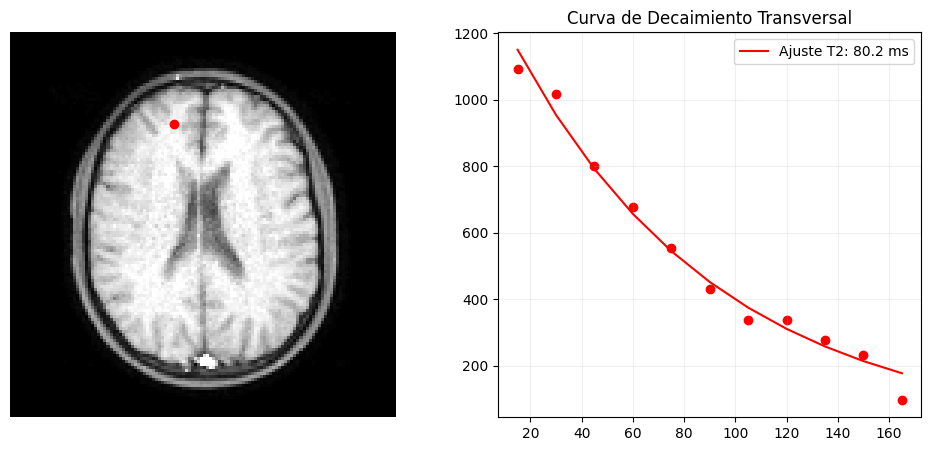

In [ ]:
# @title  Visualizador de Física de Tejidos { run: "auto" }
pixel_x = 54 # @param {type:"slider", min:0, max:127, step:1}
pixel_y = 30 # @param {type:"slider", min:0, max:127, step:1}
modo = "T2 (Decaimiento)" # @param ["T1 (Recuperación)", "T2 (Decaimiento)"]

señal_raw = IM_matrix[pixel_y, pixel_x, :]
tiempos = np.arange(1, len(señal_raw) + 1) * 15 # Asumiendo pasos de 15ms

plt.figure(figsize=(12, 5))

# Imagen de referencia
plt.subplot(1, 2, 1)
vmax = np.percentile(IM_matrix[:,:,0], 98)
plt.imshow(IM_matrix[:,:,0], cmap='gray', vmax=vmax)
plt.plot(pixel_x, pixel_y, 'ro')
plt.axis('off')

# Gráfico de la curva
plt.subplot(1, 2, 2)
if modo == "T1 (Recuperación)":
    # --- TRUCO DE RECONSTRUCCIÓN T1 ---
    idx_min = np.argmin(señal_raw)
    señal_real = señal_raw.copy()
    señal_real[:idx_min] = -señal_real[:idx_min] # Invertimos fase inicial

    def modelo_t1(t, A, B, T1): return A - B * np.exp(-t / T1)
    popt, _ = curve_fit(modelo_t1, tiempos, señal_real, p0=[max(señal_real), 2*max(señal_real), 800])

    plt.scatter(tiempos, señal_real, color='blue', label='Datos corregidos')
    plt.plot(tiempos, modelo_t1(tiempos, *popt), 'b-', label=f'Ajuste T1: {abs(popt[2]):.1f} ms')
    plt.title("Curva de Recuperación Longitudinal")
else:
    def modelo_t2(t, S0, T2): return S0 * np.exp(-t / T2)
    popt, _ = curve_fit(modelo_t2, tiempos, señal_raw, p0=[max(señal_raw), 80])
    plt.scatter(tiempos, señal_raw, color='red')
    plt.plot(tiempos, modelo_t2(tiempos, *popt), 'r-', label=f'Ajuste T2: {popt[1]:.1f} ms')
    plt.title("Curva de Decaimiento Transversal")

plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# **5. Cálculo de Relajación Transversal (Mapa T2)**

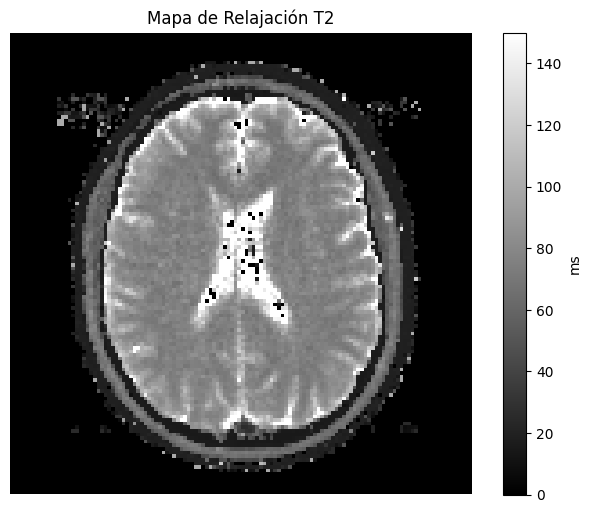

In [ ]:
# @title  Calcular Mapa T2 { run: "auto" }
te_spacing = 15 # @param {type:"number"}
umbral_ruido = 440 # @param {type:"slider", min:50, max:500, step:10}

def generar_t2(matrix, te_step):
    r, c, ecos = matrix.shape
    tes = np.arange(1, ecos + 1) * te_step
    mapa = np.zeros((r, c))

    # Ajuste lineal píxel a píxel
    for i in range(r):
        for j in range(c):
            y = np.log(np.maximum(matrix[i, j, :], 1e-6))
            m, b = np.polyfit(tes, y, 1)
            if m < 0:
                val = -1.0 / m
                mapa[i, j] = val if val < umbral_ruido else 0
    return mapa

mapa_t2 = generar_t2(IM_matrix, te_spacing)

plt.figure(figsize=(8,6))
plt.imshow(mapa_t2, cmap='gray', vmin=0, vmax=150)
plt.colorbar(label="ms")
plt.title("Mapa de Relajación T2")
plt.axis('off')
plt.show()


# **6. Cálculo de Relajación Longitudinal (Mapa T1)**

/tmp/ipykernel_10408/1523034121.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(modelo_ir, tis, y, p0=[max(y), 2*max(y), 800], maxfev=500)
/tmp/ipykernel_10408/1523034121.py:5: RuntimeWarning: overflow encountered in exp
  return A - B * np.exp(-ti / T1_star)


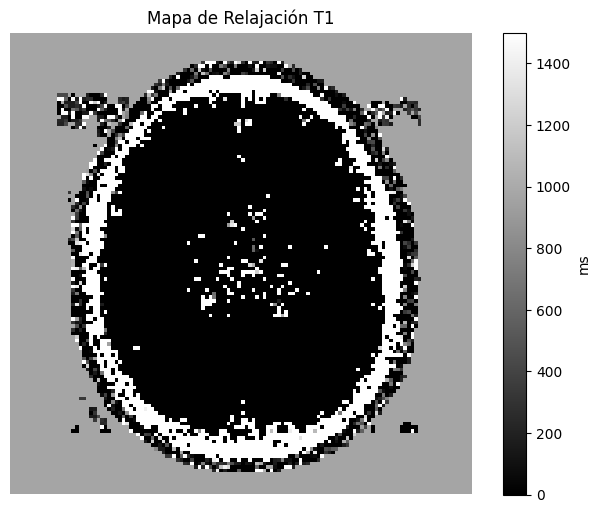

In [ ]:
# @title  Calcular Mapa T1 { run: "auto" }
rango_ti_max = 3000 # @param {type:"number"}

def modelo_ir(ti, A, B, T1_star):
    return A - B * np.exp(-ti / T1_star)

def generar_t1(matrix):
    r, c, n_ti = matrix.shape
    tis = np.linspace(100, rango_ti_max, n_ti)
    mapa = np.zeros((r, c))

    for i in range(r):
        for j in range(c):
            y = matrix[i, j, :]
            try:
                popt, _ = curve_fit(modelo_ir, tis, y, p0=[max(y), 2*max(y), 800], maxfev=500)
                t1 = popt[2] * (popt[1]/popt[0] - 1)
                mapa[i, j] = np.abs(t1) if t1 < 2500 else 0
            except: continue
    return mapa

mapa_t1 = generar_t1(IM_matrix)

plt.figure(figsize=(8,6))
plt.imshow(mapa_t1, cmap='gray', vmin=0, vmax=1500)
plt.colorbar(label="ms")
plt.title("Mapa de Relajación T1")
plt.axis('off')
plt.show()

# **7. Mapas y Análisis de Tejidos**

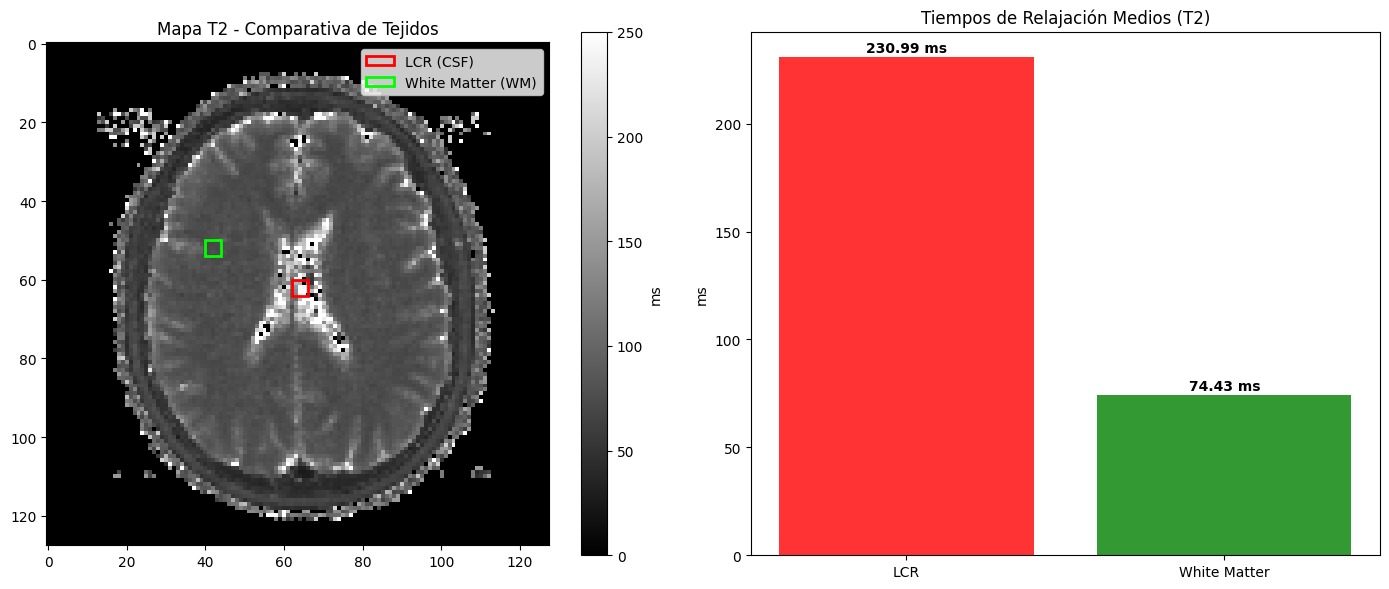

In [ ]:
# @title Mapas y Análisis de Tejidos { run: "auto" }
ver_mapa = "T2" # @param ["T1", "T2"]

def generar_mapa_t2(data):
    r, c, ecos = data.shape
    tes = np.arange(1, ecos + 1) * 15
    res = np.zeros((r, c))
    for i in range(r):
        for j in range(c):
            val_seguro = np.maximum(data[i, j, :], 1.0)
            y = np.log(val_seguro)
            m, b = np.polyfit(tes, y, 1)
            if m < 0:
                t = -1.0/m
                res[i, j] = t if t < 500 else 0
    return res

mapa_final = generar_mapa_t2(IM_matrix) if ver_mapa == "T2" else np.mean(IM_matrix, axis=2)

# --- COORDENADAS AJUSTADAS (Mismo tamaño 4x4) ---
# LCR (Rojo): Ventrículos
roi_red_coords = {'y': slice(60, 64), 'x': slice(62, 66)}
# White Matter (Verde): Centro del hemisferio (Cápsula interna/Centro semioval)
roi_green_coords = {'y': slice(50, 54), 'x': slice(40, 44)}

val_red = mapa_final[roi_red_coords['y'], roi_red_coords['x']]
val_green = mapa_final[roi_green_coords['y'], roi_green_coords['x']]

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Mapa con rectángulos
vmax_map = 250 if ver_mapa == "T2" else np.percentile(mapa_final, 98)
im = ax[0].imshow(mapa_final, cmap='gray', vmin=0, vmax=vmax_map)

# ROI Roja: LCR
ax[0].add_patch(plt.Rectangle((62, 60), 4, 4, color='red', fill=False, linewidth=2, label='LCR (CSF)'))
# ROI Verde: White Matter (Mismo tamaño 4x4)
ax[0].add_patch(plt.Rectangle((40, 50), 4, 4, color='lime', fill=False, linewidth=2, label='White Matter (WM)'))

ax[0].set_title(f"Mapa {ver_mapa} - Comparativa de Tejidos")
ax[0].legend()
plt.colorbar(im, ax=ax[0], label="ms")

# 2. Gráfico de Barras
tiempos = [np.mean(val_red[val_red>0]), np.mean(val_green[val_green>0])]
ax[1].bar(['LCR', 'White Matter'], tiempos, color=['red', 'green'], alpha=0.8)
ax[1].set_title(f"Tiempos de Relajación Medios ({ver_mapa})")
ax[1].set_ylabel("ms")

for i, v in enumerate(tiempos):
    ax[1].text(i, v + 2, f"{v:.2f} ms", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

<div style="background-color: #fff3cd; color: #856404; padding: 15px; border: 1px solid #ffeeba; border-radius: 5px; margin-top: 20px;">
    <h3 style="margin-top: 0;">⚠️ <b>Aviso de Limitación y Propósito Educativo</b></h3>
    <p>Este notebook ha sido desarrollado exclusivamente con fines <b>educativos y académicos</b> en el marco del <i>Workshop: Decodificación de Gliomas con ML e IA Interpretable</i>.</p>
    <ul>
        <li><b>No es una herramienta médica:</b> Los resultados, mapas de relajación (T1/T2) y análisis generados no deben utilizarse para el diagnóstico, pronóstico o tratamiento de ninguna condición médica real.</li>
        <li><b>Limitaciones Técnicas:</b> Los algoritmos de ajuste exponencial y los criterios de umbralización aquí presentados son simplificaciones para facilitar la enseñanza y pueden no considerar todas las variables físicas y biológicas presentes en un entorno clínico real.</li>
        <li><b>Responsabilidad:</b> El uso de este código fuera del contexto del taller es responsabilidad exclusiva del usuario.</li>
    </ul>
</div>